In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import re
from PIL.ImageColor import colormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root folder named '{project_folder_name}'.")
print("Project root path:"+ str(project_root))
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.fuelcell import PEMFC_1D
from model.coefficients import *
from configuration.initialize import *

Project root path:d:\PEMFC\MFC2024


In [3]:
load_points = [10, 20, 30, 40, 50]

In [4]:
simulation_log = {}
for I_LOAD in load_points:
    print(f"Simulating for I_LOAD = {I_LOAD} A...")
    model = PEMFC_1D(parameters, operating_inputs)
    sol = model.solve(I_LOAD/parameters['Aact'])
    simulation_log[I_LOAD] = sol

Simulating for I_LOAD = 10 A...
Simulating for I_LOAD = 20 A...
Simulating for I_LOAD = 30 A...
Simulating for I_LOAD = 40 A...
Simulating for I_LOAD = 50 A...


d:\PEMFC\MFC2024\model\fuelcell.py:103: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  s[i_node] = np.max([fsolve(s_gdl_func, x0=0.1)[0], 0])


In [7]:
sol

{'Jnet': np.float64(0.003040184403856681),
 'Jmem': np.float64(0.0031374723248037153),
 'lambda_ccl': np.float64(16.039785202016443),
 'lambda_acl': np.float64(3.5954284225820206),
 'C_v_ccl': np.float64(23.686211527408155),
 'C_v_acl': np.float64(1.6499358678574665),
 's_front_cgdl': 0.0002,
 's_front_agdl': 0,
 'C_v_cgdl': array([4.59279892, 4.59279892, 4.59279892, 4.59279892, 4.59279892,
        4.59279892, 4.59279892, 4.59279892, 4.59279892, 4.59279892]),
 'C_v_agdl': array([1.24941797, 1.26054346, 1.27166896, 1.28279446, 1.29391996,
        1.30504545, 1.31617095, 1.32729645, 1.33842194, 1.34954744]),
 'lambda_mem': [np.float64(16.039785202016443),
  np.float64(13.765599933311258),
  np.float64(11.832361759925252),
  np.float64(10.188955707451452),
  np.float64(8.791929986312718),
  np.float64(7.60434712291425),
  np.float64(6.594807329840074),
  np.float64(5.736618292922073),
  np.float64(5.007089424284272),
  np.float64(4.386931921355459)],
 's_cgdl': array([0.25497315, 0.255122

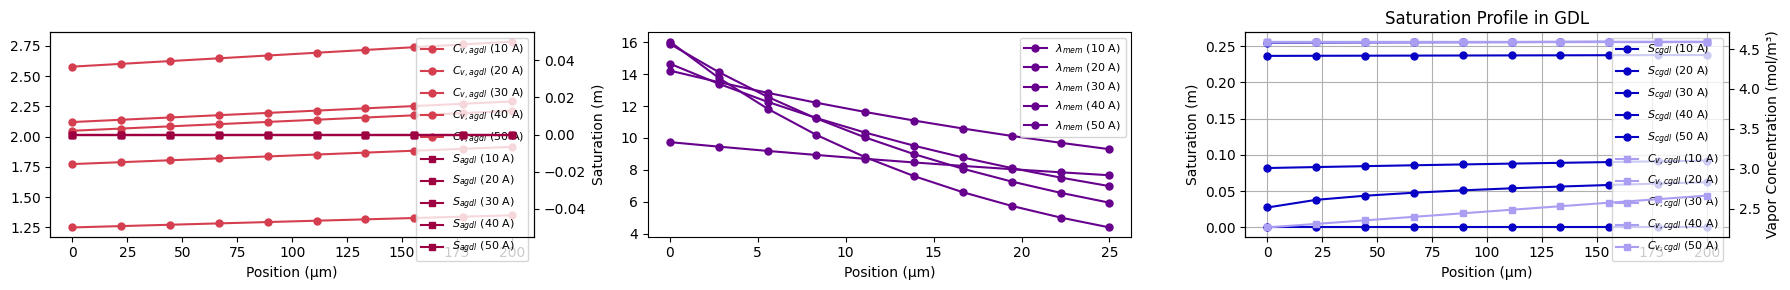

In [9]:
fig, axes = plt.subplots(nrows=1, ncols= 3, figsize=(18, 3))
ax0_2 = axes[0].twinx()
ax2_2 = axes[2].twinx()
x_gdl = np.linspace(0, parameters["Hgdl"]*1e6, 10)
x_mem = np.linspace(0, parameters["Hmem"]*1e6, 10)

for I_LOAD, sol in simulation_log.items():
    axes[0].plot(x_gdl, sol["C_v_agdl"], marker='o', markersize=5, color = "#d53e4f", label = f"$C_{{v, agdl}}$ ({I_LOAD} A)")
    ax0_2.plot(x_gdl, sol["s_agdl"], marker='s', markersize=5, color = "#9e0142", label = f"$S_{{agdl}}$ ({I_LOAD} A)")
    axes[1].plot(x_mem, sol["lambda_mem"], marker='o', markersize=5, color = "#67008d", label = rf"$\lambda_{{mem}}$ ({I_LOAD} A)")
    axes[2].plot(x_gdl, sol["s_cgdl"], marker='o', markersize=5, color = "#0700c5", label = f"$S_{{cgdl}}$ ({I_LOAD} A)")
    ax2_2.plot(x_gdl, sol["C_v_cgdl"], marker='s', markersize=5, color = "#aa9ef2", label = f"$C_{{v, cgdl}}$ ({I_LOAD} A)")

axes[0].set_xlabel('Position (µm)')
axes[1].set_xlabel('Position (µm)')
axes[2].set_xlabel('Position (µm)')
axes[2].set_ylabel('Saturation (m)')
axes[2].set_title('Saturation Profile in GDL')
axes[2].grid(True)
ax0_2.set_ylabel('Saturation (m)')
ax2_2.set_ylabel('Vapor Concentration (mol/m³)')

handles, labels = axes[0].get_legend_handles_labels()
handles2, labels2 = ax0_2.get_legend_handles_labels()
axes[0].legend(handles + handles2, labels + labels2, fontsize=8)
axes[1].legend(fontsize=8)
handles, labels = axes[2].get_legend_handles_labels()
handles2, labels2 = ax2_2.get_legend_handles_labels()
axes[2].legend(handles + handles2, labels + labels2, fontsize=8)
plt.tight_layout()
plt.show()